# 07 · Бенчмарк: сравнение методов на всех наборах

**Вопрос.** Какой из существующих методов (настройки EPDE или классическая
разреженная регрессия) надёжнее всего восстанавливает уравнение, по классам задач и
уровням шума?

**Протокол.** `configs/_base.yaml`: один пул токенов для всех задач; файлы наборов
добавляют только необходимое. Варианты (`configs/variants.yaml`):

| вариант | что меняется |
|---|---|
| `default` | EPDE на domain_refactor как есть: wape + нестабильность chi2 + VWSR, производные FD |
| `legacy` | старый EPDE: L2 + LASSO, вторая цель -- сложность |
| `poly` | производные полиномиальной аппроксимацией |
| `knee` | разреживание по «колену» кривой |
| `instab_cv` | нестабильность через кросс-валидацию |
| `trig_native` | штатные тригонометрические токены библиотеки (эффект «корзин» частот) |
| `pysindy` | SINDy/PDE-FIND: STLSQ на фиксированной библиотеке из тех же «кирпичей» |

**Метрики.** *Истина на фронте*: у какого-то решения итогового фронта Парето ровно
истинный набор членов (коэффициенты не учитываются, документированные эквивалентные
формы засчитываются) -- метрика прежнего бенчмарка группы. *Компромиссный выбор*:
одно уравнение, выбранное с фронта без знания истины (минимальная сумма нормированных
целей).

**Запуск** (любая ОС; продолжается после обрыва; каждый запуск в своём процессе):

```
python projects/pic/bench.py campaign --suite core --variants default,legacy,poly,knee,instab_cv,pysindy \
       --noise 0,1,5 --seeds 0-2 --workers 4 --name nir1_core
python projects/pic/bench.py report projects/pic/results/nir1_core
```

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


In [2]:
import pandas as pd
from IPython.display import Markdown, display, Image
from epde_bench.paths import RESULTS_DIR
CAMPAIGN = RESULTS_DIR / os.environ.get('EPDE_BENCH_NOTEBOOK_CAMPAIGN', 'nir1_core')
print('campaign results available:', CAMPAIGN.exists())

campaign results available: True


In [3]:
from epde_bench.report import make_report, load_runs
if (CAMPAIGN / 'runs').exists():
    out = make_report(CAMPAIGN)
    display(Markdown((out / 'summary.md').read_text(encoding='utf-8')))
else:
    print('run the campaign first (command above)')

report written to projects/pic\results\rest_ready_smoke_final\report


# Кампания `rest_ready_smoke_final`

Запусков: 2 (ok: 2).
Успех -- истинная структура (или принятая эквивалентная форма) есть на итоговом фронте Парето; «выбор» -- уравнение, выбранное с фронта без знания истины (компромисс), верно. В ячейках: k/n (доля, 95 % интервал Уилсона). Ошибки и таймауты считаются промахами. pending — запланировано, ещё не выполнено; unsupported — метод не поддерживает задачу. Эти два статуса исключены из знаменателей успеха.

## Шум 0 %

### Истина на фронте Парето

| набор | default | pysindy |
|---|---|---|
| ode | 1/1 (100%, 21-100) | 1/1 (100%, 21-100) |

### Компромиссный выбор верен

| набор | default | pysindy |
|---|---|---|
| ode | 1/1 (100%, 21-100) | 1/1 (100%, 21-100) |

## Лучший вариант по классу задач

Среднее по общим поддерживаемым наборам класса от доли успехов на наборе; набор исключён из рейтинга, если хотя бы один вариант имеет unsupported или ещё не имеет выполненных запусков. При равенстве решает компромиссный выбор, затем скорость.

| класс | шум, % | лучший вариант | успех (фронт) | успех (выбор) | медиана времени, с |
|---|---|---|---|---|---|
| ОДУ | 0 | pysindy | 100% | 100% | 3 |

## Все наборы вместе (средний успех на фронте)

| вариант | 0.0 |
|---|---|
| default | 100% |
| pysindy | 100% |

## Медианное время поиска, с

| набор | default | pysindy |
|---|---|---|
| ode | 27.8 | 2.6 |


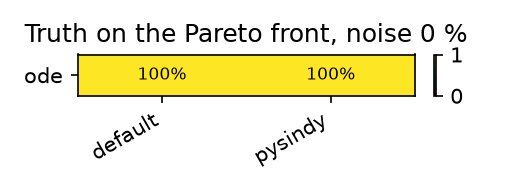

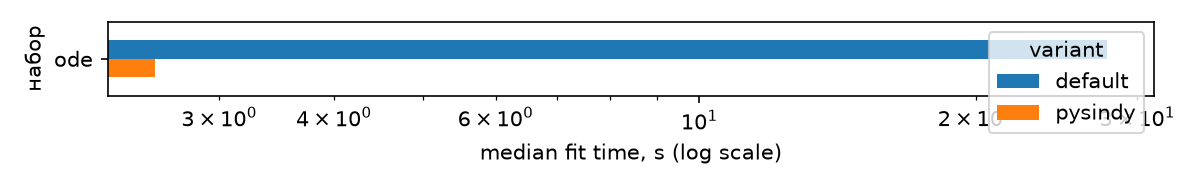

In [4]:
for png in sorted((CAMPAIGN / 'report').glob('fig_*.png')):
    display(Image(filename=str(png)))

In [5]:
# Use report tables: pending/unsupported must not become ordinary failures.
if (CAMPAIGN / 'report' / 'success_front.csv').exists():
    display(pd.read_csv(CAMPAIGN / 'report' / 'success_front.csv'))
    display(pd.read_csv(CAMPAIGN / 'report' / 'ranking.csv'))
else:
    print('no campaign results yet')

,dataset,variant,noise,kind,runs,planned,pending,unsupported,success_front,success_selected,median_fit_s,median_coef_error,ranking_comparable
0,ode,default,0.0,ode,1,1,0,0,1.0,1.0,27.766170,0.005792,True
1,ode,pysindy,0.0,ode,1,1,0,0,1.0,1.0,2.554435,0.006261,True


,kind,noise,variant,success_front,success_selected,median_fit_s
0,ode,0.0,pysindy,1.0,1.0,2.554435
1,ode,0.0,default,1.0,1.0,27.766170
